<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [3]:
# Your code here
df = pd.read_csv('./data/College.csv')
df = df.rename(columns={'Unnamed: 0': 'School'})
df.head()

,School,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [4]:
# Your code here
# Your code here
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   School       777 non-null    str    
 1   Private      777 non-null    str    
 2   Apps         777 non-null    int64  
 3   Accept       777 non-null    int64  
 4   Enroll       777 non-null    int64  
 5   Top10perc    777 non-null    int64  
 6   Top25perc    777 non-null    int64  
 7   F.Undergrad  777 non-null    int64  
 8   P.Undergrad  777 non-null    int64  
 9   Outstate     777 non-null    int64  
 10  Room.Board   777 non-null    int64  
 11  Books        777 non-null    int64  
 12  Personal     777 non-null    int64  
 13  PhD          777 non-null    str    
 14  Terminal     777 non-null    int64  
 15  S.F.Ratio    777 non-null    float64
 16  perc.alumni  777 non-null    int64  
 17  Expend       777 non-null    int64  
 18  Grad.Rate    777 non-null    int64  
dtypes: float64(1), int6

School         0
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64

#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [5]:
# Your code here
df['PhD'].describe()

count     777
unique     78
top         ?
freq       29
Name: PhD, dtype: object

In [6]:
# Your code here
df['PhD'] = df['PhD'].replace('?', None)
df['PhD'] = pd.to_numeric(df['PhD'])
df['PhD'] = df['PhD'].fillna(df['PhD'].median())

df['PhD'].describe()

count    777.000000
mean      72.611326
std       16.014355
min        8.000000
25%       62.000000
50%       75.000000
75%       85.000000
max      103.000000
Name: PhD, dtype: float64

#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [7]:
df['Grad.Rate'].describe()

count    777.00000
mean      65.46332
std       17.17771
min       10.00000
25%       53.00000
50%       65.00000
75%       78.00000
max      118.00000
Name: Grad.Rate, dtype: float64

In [9]:
# Your code here
df['Grad.Rate'] = df['Grad.Rate'].clip(upper=100)
df['Grad.Rate'].describe()

count    777.000000
mean      65.440154
std       17.118804
min       10.000000
25%       53.000000
50%       65.000000
75%       78.000000
max      100.000000
Name: Grad.Rate, dtype: float64

## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [10]:
%%writefile myutils.py
import pandas as pd
import numpy as np


def skew_calc(df):
    """
    Diagnoses skewness for every numeric column in a DataFrame and recommends a transformation based on the column's skewness and
    minimum value. Binary, encoded, and ID columns are excluded, since skewness isn't a meaningful for them.
    It returns a DataFrame with the following columns:
    Feature, Skewness, Degree, Direction, Recommended Transformation
    """
    rows = []
    numeric_cols = df.select_dtypes(include=np.number).columns
    
    for col in numeric_cols:
        n_unique = df[col].nunique()
        if n_unique <= 2 or n_unique == len(df):
            continue

        skewness = df[col].skew()

        if skewness < -1:
            degree, direction = 'Highly Skewed', 'Left'
        elif skewness < -0.5:
            degree, direction = 'Moderately Skewed', 'Left'
        elif skewness <= 0.5:
            degree, direction = 'Normal', 'Symmetrical'
        elif skewness <= 1:
            degree, direction = 'Moderately Skewed', 'Right'
        else:
            degree, direction = 'Highly Skewed', 'Right'

        min_val = df[col].min()


        if degree == 'Normal':
            transformation = 'None'
        elif direction == 'Right' and min_val == 0:
            transformation = 'Log Plus One'
        elif min_val < 0:
            transformation = 'Yeo-Johnson'
        else:
            transformation = 'Box-Cox'
            
        rows.append({
            'Feature': col,
            'Skewness': skewness,
            'Degree': degree,
            'Direction': direction,
            'Recommended Transformation': transformation
        })

    return pd.DataFrame(rows)

Writing myutils.py


In [11]:
# Now import the function from myutils
from myutils import skew_calc

In [12]:
def plot_transformations(df, skew_table):
    """
    Applies the recommended transformation to each column, then plots the before and after
    distributions side by side with the skewness degree on each subplot.
    """
    to_plot = skew_table[skew_table['Recommended Transformation'] != 'None'].reset_index(drop=True)
    n = len(to_plot)

    fig, axes = plt.subplots(n, 2, figsize=(10, 3.2 * n))
    if n == 1:
        axes = axes.reshape(1, 2)

    for i, row in to_plot.iterrows():
        col = row['Feature']
        transformation = row['Recommended Transformation']
        original = df[col].dropna()

        if transformation == 'Log Plus One':
            transformed = np.log1p(original)
        elif transformation == 'Box-Cox':
            pt = PowerTransformer(method='box-cox')
            transformed = pt.fit_transform(original.values.reshape(-1, 1)).flatten()
        elif transformation == 'Yeo-Johnson':
            pt = PowerTransformer(method='yeo-johnson')
            transformed = pt.fit_transform(original.values.reshape(-1, 1)).flatten()
        else:
            transformed = original

        transformed_skew = pd.Series(transformed).skew()

        axes[i, 0].hist(original, bins=30, color='steelblue', edgecolor='white')
        axes[i, 0].set_title(f'{col} - Before (skew={row["Skewness"]:.2f})')

        axes[i, 1].hist(transformed, bins=30, color='seagreen', edgecolor='white')
        axes[i, 1].set_title(f'{col} - After {transformation} (skew={transformed_skew:.2f})')

    plt.tight_layout()
    plt.show()

#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [13]:
# Your code here
skew_table = skew_calc(df)
skew_table

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.723750,Highly Skewed,Right,Box-Cox
1,Accept,3.417727,Highly Skewed,Right,Box-Cox
2,Enroll,2.690465,Highly Skewed,Right,Box-Cox
3,Top10perc,1.413217,Highly Skewed,Right,Box-Cox
4,Top25perc,0.259340,Normal,Symmetrical,None
5,F.Undergrad,2.610458,Highly Skewed,Right,Box-Cox
6,P.Undergrad,5.692353,Highly Skewed,Right,Box-Cox
7,Outstate,0.509278,Moderately Skewed,Right,Box-Cox
8,Room.Board,0.477356,Normal,Symmetrical,None
9,Books,3.485025,Highly Skewed,Right,Box-Cox


In [ ]:
# Your code here

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.723750,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
1,Accept,3.417727,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
2,Enroll,2.690465,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
3,Top10perc,1.413217,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
4,Top25perc,0.259340,Approximately Symmetric,Positive,None needed
5,F.Undergrad,2.610458,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
6,P.Undergrad,5.692353,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
7,Outstate,0.509278,Moderately Skewed,Positive,Box-Cox or Yeo-Johnson
8,Room.Board,0.477356,Approximately Symmetric,Positive,None needed
9,Books,3.485025,Highly Skewed,Positive,Box-Cox or Yeo-Johnson


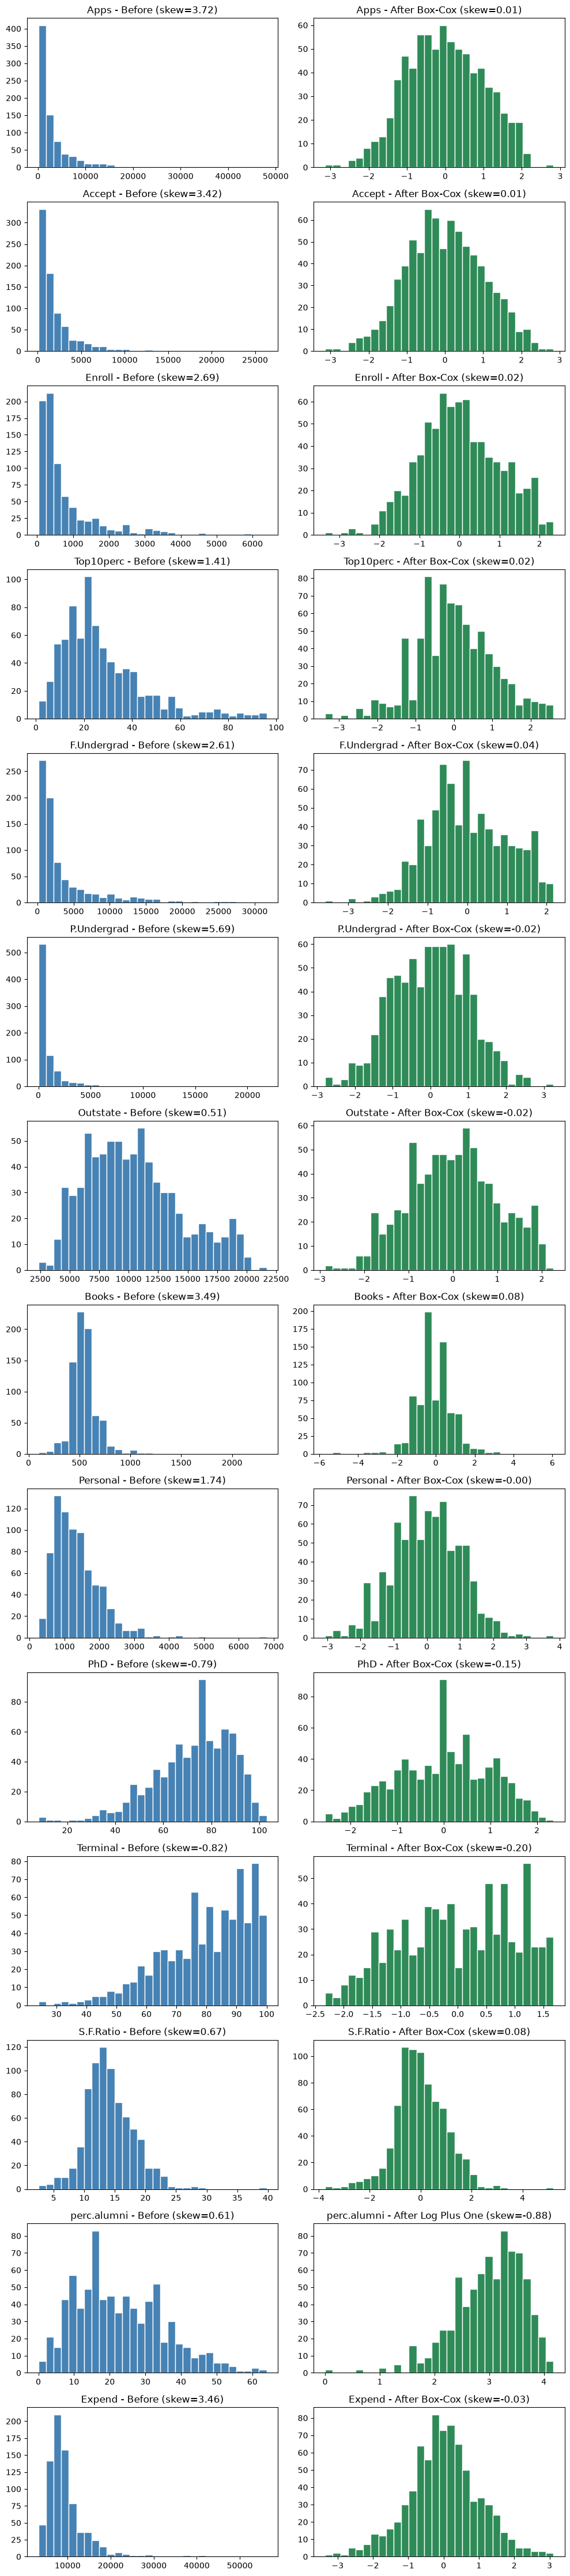

In [14]:
# Your code here
plot_transformations(df, skew_table)

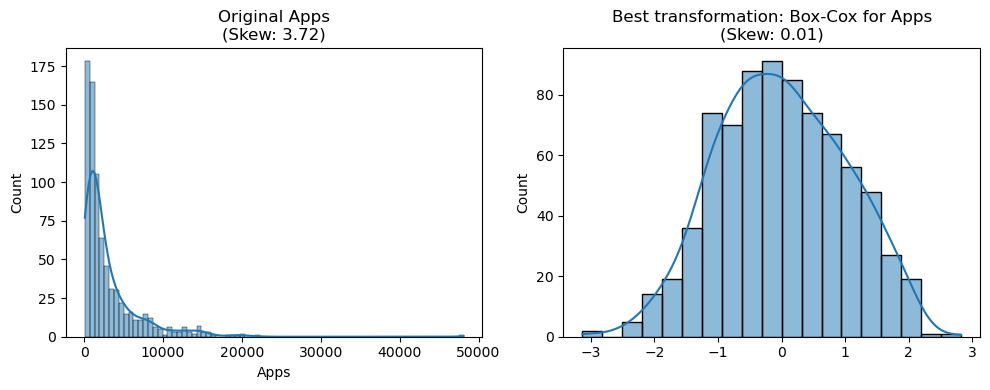

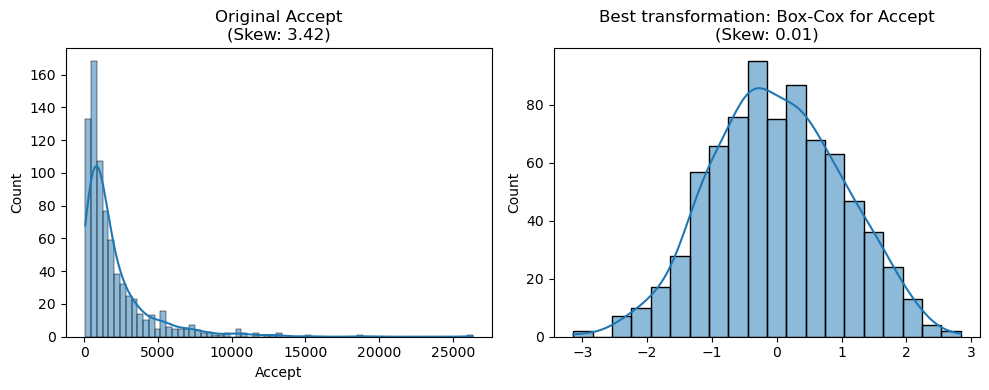

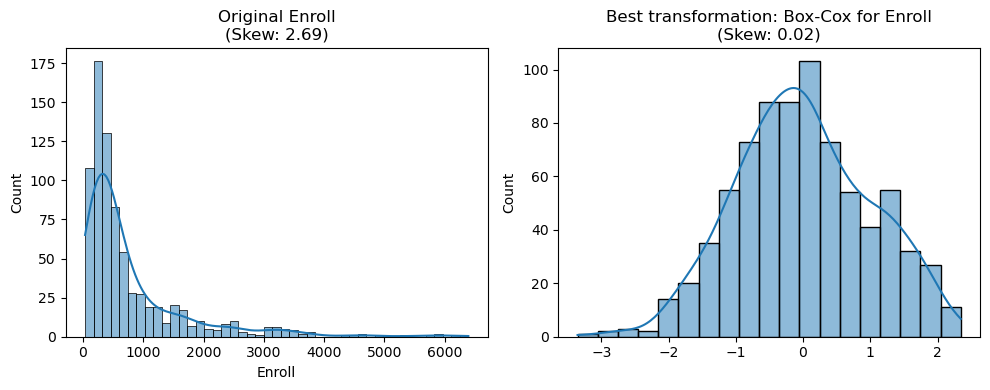

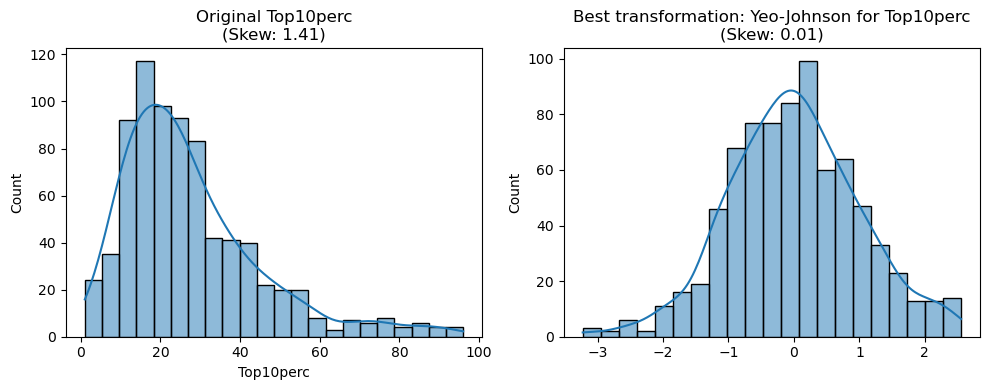

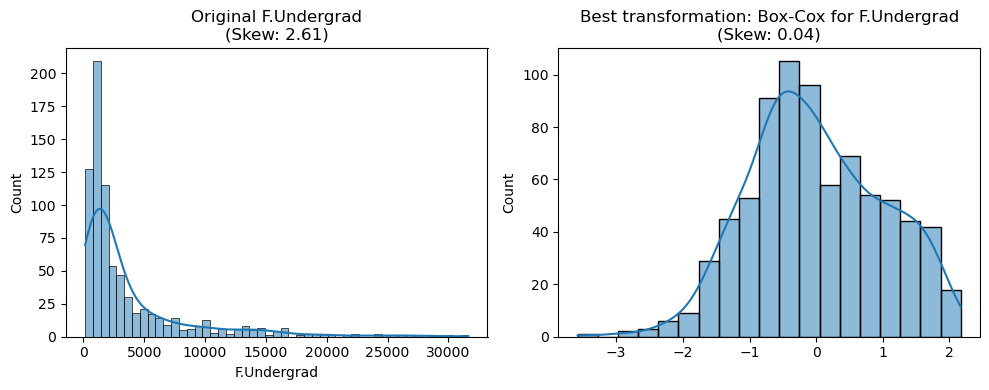

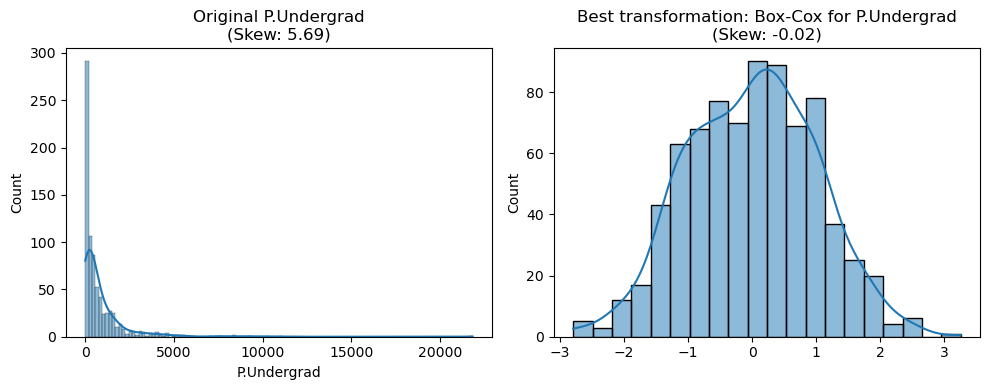

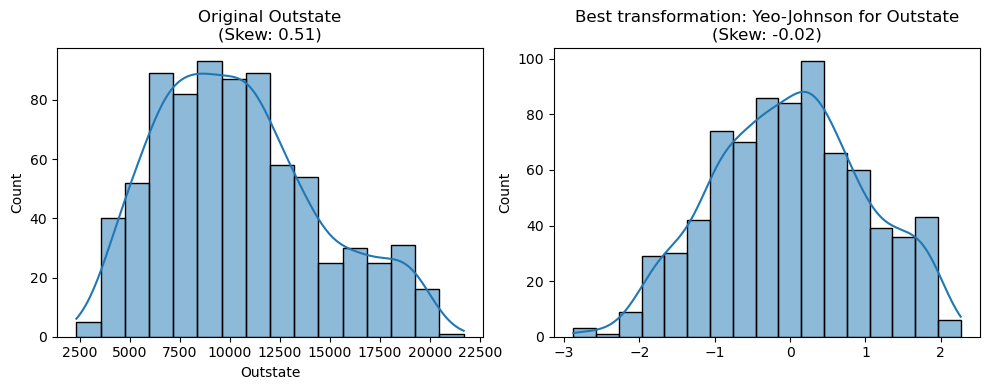

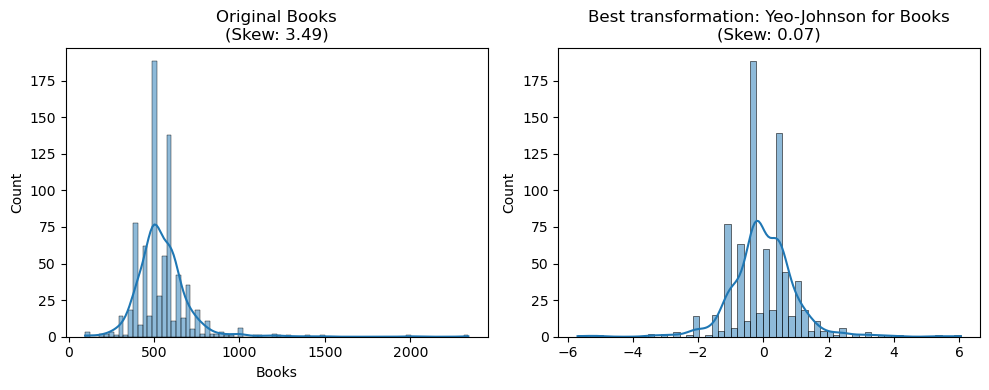

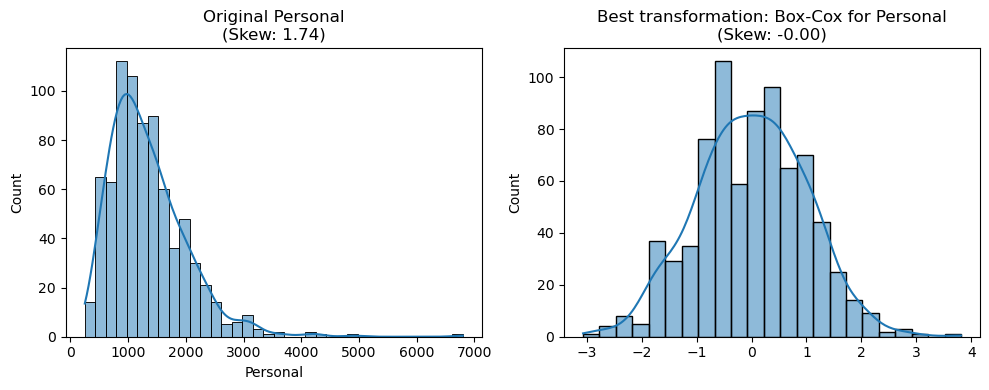

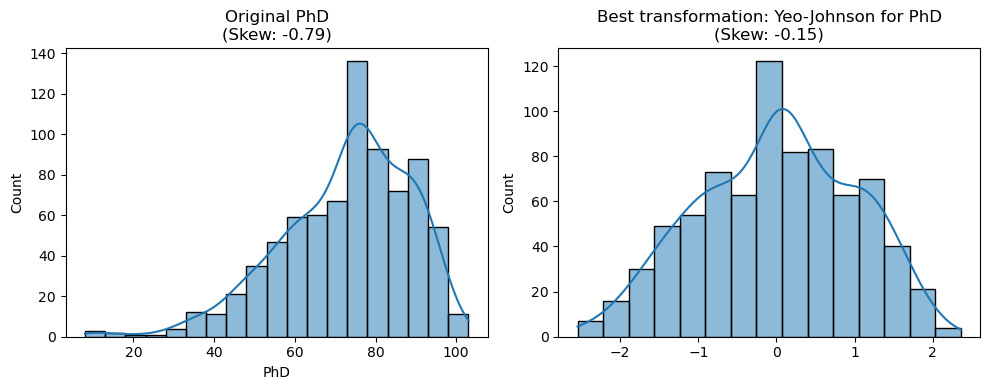

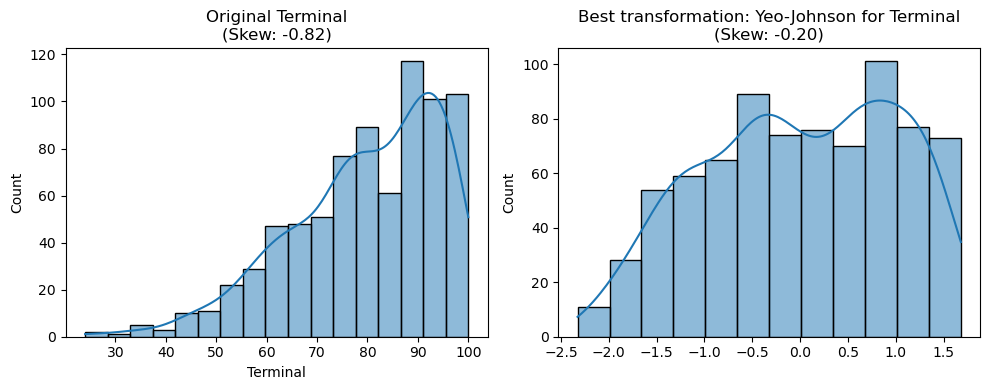

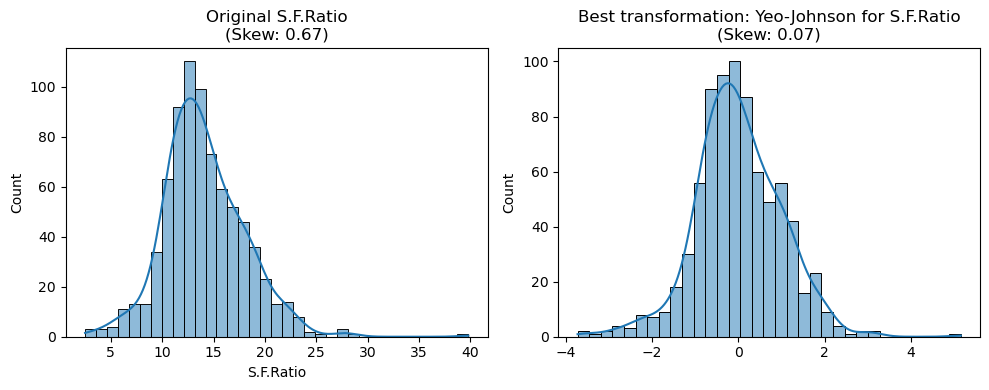

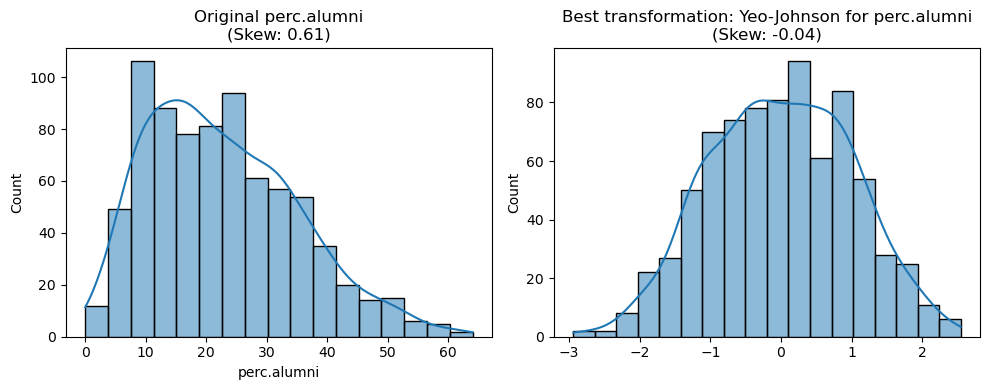

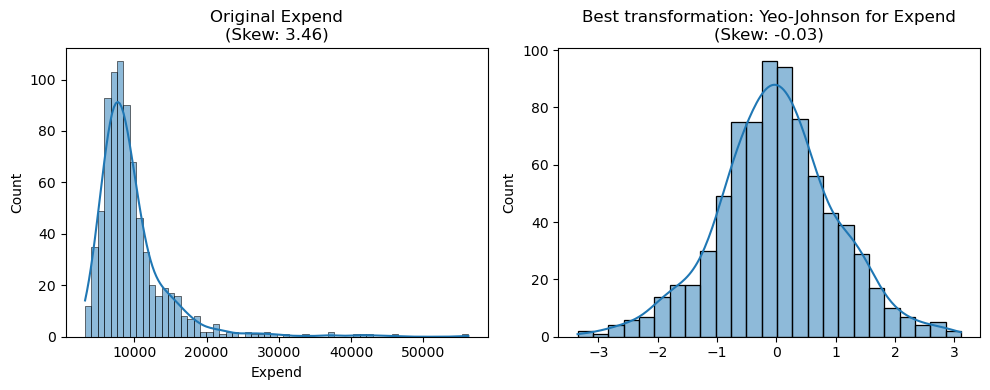

In [ ]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [15]:
trans_cols = []

for _, row in skew_table[skew_table['Recommended Transformation'] != 'None'].iterrows():
    col = row['Feature']
    transformation = row['Recommended Transformation']
    new_col = f'{col}_trans'

    if transformation == 'Log Plus One':
        df[new_col] = np.log1p(df[col])
    elif transformation == 'Box-Cox':
        pt = PowerTransformer(method='box-cox')
        df[new_col] = pt.fit_transform(df[[col]])
    elif transformation == 'Yeo-Johnson':
        pt = PowerTransformer(method='yeo-johnson')
        df[new_col] = pt.fit_transform(df[[col]])

    trans_cols.append(new_col)

print(trans_cols)
df[trans_cols].head()

['Apps_trans', 'Accept_trans', 'Enroll_trans', 'Top10perc_trans', 'F.Undergrad_trans', 'P.Undergrad_trans', 'Outstate_trans', 'Books_trans', 'Personal_trans', 'PhD_trans', 'Terminal_trans', 'S.F.Ratio_trans', 'perc.alumni_trans', 'Expend_trans']


,Apps_trans,Accept_trans,Enroll_trans,Top10perc_trans,F.Undergrad_trans,P.Undergrad_trans,Outstate_trans,Books_trans,Personal_trans,PhD_trans,Terminal_trans,S.F.Ratio_trans,perc.alumni_trans,Expend_trans
0,0.027794,0.041028,0.493375,-0.053119,0.433599,0.300156,-0.693449,-0.614254,1.271398,-0.290788,-0.282374,1.017946,2.564949,-0.491183
1,0.282920,0.485821,0.142214,-0.584905,0.365382,0.868239,0.556268,1.302365,0.456551,-2.179258,-2.248129,-0.435083,2.833213,0.552362
2,-0.113916,-0.077046,-0.315977,-0.120942,-0.636774,-0.727254,0.322011,-1.038575,-0.068655,-1.262184,-1.040711,-0.250216,3.433987,0.096393
3,-1.332769,-1.294446,-1.396388,1.614476,-1.531207,-0.974032,0.703926,-0.614254,-0.651734,1.361347,1.364588,-1.741872,3.637586,1.726997
4,-2.153050,-2.287608,-2.659212,-0.584905,-2.588901,0.625418,-0.656776,1.553608,0.456551,0.115631,-0.687052,-0.515571,1.098612,0.637044


## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [16]:
df['Accept_Rate'] = df['Accept'] / df['Apps']
df[['Apps', 'Accept', 'Accept_Rate']].head()

,Apps,Accept,Accept_Rate
0,1660,1232,0.742169
1,2186,1924,0.880146
2,1428,1097,0.768207
3,417,349,0.836930
4,193,146,0.756477


#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [17]:
bin_edges = [df['Outstate'].min() - 1, 7320, 12925, df['Outstate'].max() + 1]
bin_labels = ['Low', 'Medium', 'High']

df['Outstate_Tier'] = pd.cut(df['Outstate'], bins=bin_edges, labels=bin_labels)
df[['Outstate', 'Outstate_Tier']].head()

,Outstate,Outstate_Tier
0,7440,Medium
1,12280,Medium
2,11250,Medium
3,12960,High
4,7560,Medium


#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [18]:
tier_order = {'Low': 0, 'Medium': 1, 'High': 2}
df['Outstate_Tier_ordinal'] = df['Outstate_Tier'].map(tier_order)
df[['Outstate_Tier', 'Outstate_Tier_ordinal']].head()

,Outstate_Tier,Outstate_Tier_ordinal
0,Medium,1
1,Medium,1
2,Medium,1
3,High,2
4,Medium,1


#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [19]:
df['Private_binary'] = df['Private'].map({'Yes': 1, 'No': 0})
df[['Private', 'Private_binary']].head()

,Private,Private_binary
0,Yes,1
1,Yes,1
2,Yes,1
3,Yes,1
4,Yes,1


## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [20]:
cols_to_scale = trans_cols + ['Accept_Rate', 'Outstate_Tier_ordinal', 'Private_binary']

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[cols_to_scale])

scaled_cols = [f'{c}_scaled' for c in cols_to_scale]
df[scaled_cols] = scaled_values

df[scaled_cols].head()

,Apps_trans_scaled,Accept_trans_scaled,Enroll_trans_scaled,Top10perc_trans_scaled,F.Undergrad_trans_scaled,P.Undergrad_trans_scaled,Outstate_trans_scaled,Books_trans_scaled,Personal_trans_scaled,PhD_trans_scaled,Terminal_trans_scaled,S.F.Ratio_trans_scaled,perc.alumni_trans_scaled,Expend_trans_scaled,Accept_Rate_scaled,Outstate_Tier_ordinal_scaled,Private_binary_scaled
0,0.027794,0.041028,0.493375,-0.053119,0.433599,0.300156,-0.693449,-0.614254,1.271398,-0.290788,-0.282374,1.017946,-0.722701,-0.491183,-0.032372,0.001819,0.612553
1,0.282920,0.485821,0.142214,-0.584905,0.365382,0.868239,0.556268,1.302365,0.456551,-2.179258,-2.248129,-0.435083,-0.284489,0.552362,0.906193,0.001819,0.612553
2,-0.113916,-0.077046,-0.315977,-0.120942,-0.636774,-0.727254,0.322011,-1.038575,-0.068655,-1.262184,-1.040711,-0.250216,0.696881,0.096393,0.144750,0.001819,0.612553
3,-1.332769,-1.294446,-1.396388,1.614476,-1.531207,-0.974032,0.703926,-0.614254,-0.651734,1.361347,1.364588,-1.741872,1.029462,1.726997,0.612225,1.415126,0.612553
4,-2.153050,-2.287608,-2.659212,-0.584905,-2.588901,0.625418,-0.656776,1.553608,0.456551,0.115631,-0.687052,-0.515571,-3.117978,0.637044,0.064955,0.001819,0.612553


#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

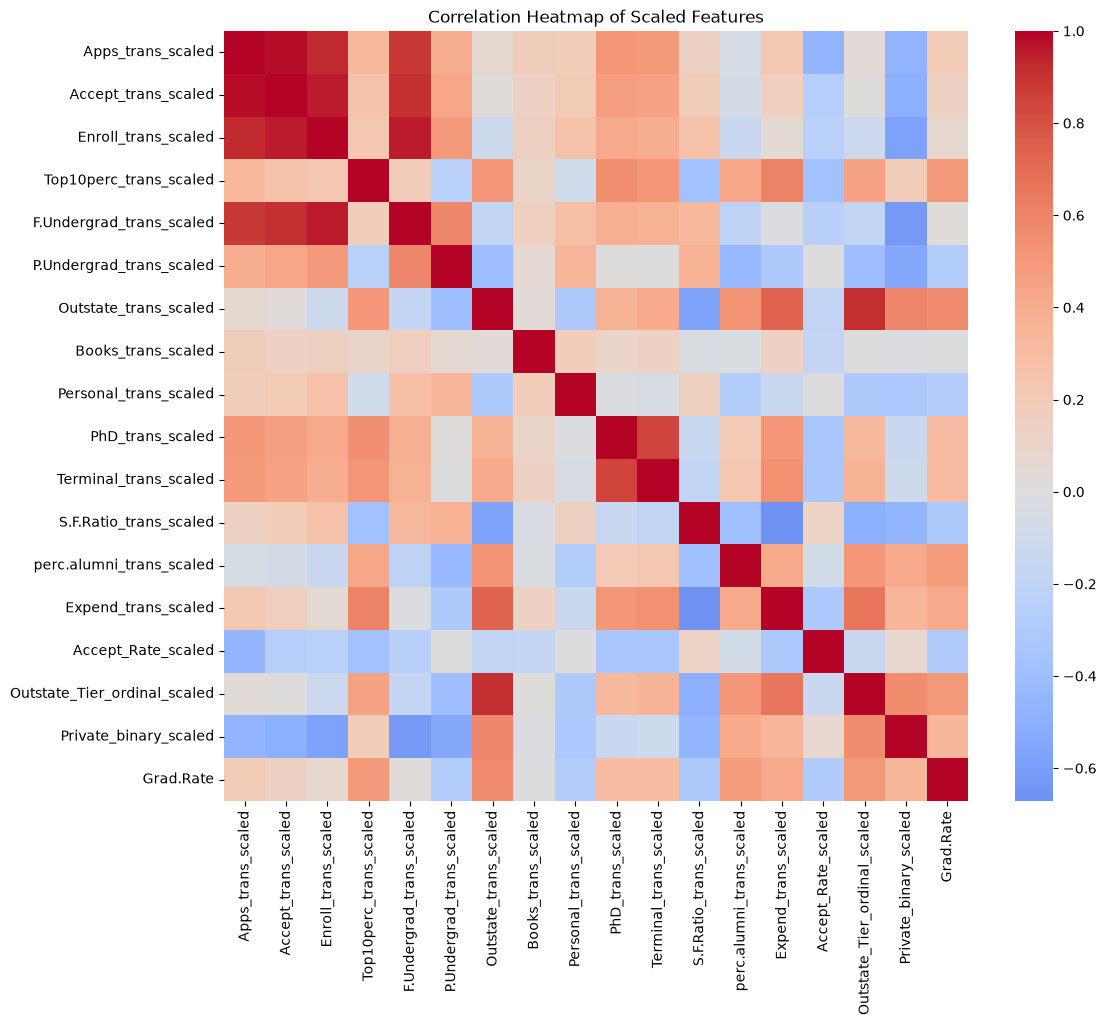

Correlation with Grad.Rate, sorted:
Outstate_trans_scaled           0.569032
Outstate_Tier_ordinal_scaled    0.500290
Top10perc_trans_scaled          0.495577
perc.alumni_trans_scaled        0.490135
Expend_trans_scaled             0.417198
Private_binary_scaled           0.336490
S.F.Ratio_trans_scaled         -0.310808
Terminal_trans_scaled           0.310527
PhD_trans_scaled                0.303660
Accept_Rate_scaled             -0.289299
P.Undergrad_trans_scaled       -0.278290
Personal_trans_scaled          -0.269853
Apps_trans_scaled               0.202301
Accept_trans_scaled             0.147975
Enroll_trans_scaled             0.078194
F.Undergrad_trans_scaled        0.033344
Books_trans_scaled             -0.005470
Name: Grad.Rate, dtype: float64


In [21]:
corr_cols = scaled_cols + ['Grad.Rate']
corr = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Scaled Features')
plt.show()

print('Correlation with Grad.Rate, sorted:')
print(corr['Grad.Rate'].drop('Grad.Rate').sort_values(key=abs, ascending=False))

## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [22]:
base_cols = [c.replace('_trans', '') for c in trans_cols]

untrans_features = base_cols + ['Accept_Rate', 'Outstate_Tier_ordinal', 'Private_binary']
trans_features = trans_cols + ['Accept_Rate', 'Outstate_Tier_ordinal', 'Private_binary']

target = 'Grad.Rate'

X_raw = df[untrans_features]
X_trans = df[trans_features]
y = df[target]

X_raw_train, X_raw_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)
X_trans_train, X_trans_test, _, _ = train_test_split(X_trans, y, test_size=0.2, random_state=42)

print(X_raw_train.shape, X_trans_train.shape)

(621, 17) (621, 17)


#### 15. Fit a linear regression using the raw predictors


In [23]:
untrans_predictors = untrans_features

model_raw = LinearRegression()
model_raw.fit(X_raw_train, y_train)

r2_raw = model_raw.score(X_raw_test, y_test)
print(f'R2 (raw predictors): {r2_raw:.4f}')

R2 (raw predictors): 0.4472


#### 16. Fit the same model using the log-transformed predictors

In [24]:
trans_predictors = trans_features

model_trans = LinearRegression()
model_trans.fit(X_trans_train, y_train)

r2_trans = model_trans.score(X_trans_test, y_test)
print(f'R2 (log/transformed predictors): {r2_trans:.4f}')

R2 (log/transformed predictors): 0.4748


#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

In [27]:
print(f'R2 with raw predictors:         {r2_raw:.4f}')
print(f'R2 with transformed predictors:  {r2_trans:.4f}')
print(f'Improvement:                     {r2_trans - r2_raw:+.4f}')

if r2_trans > r2_raw:
    print(
    "Transforming heavily right-skewed count features (e.g., Apps, Accept, "
    "F.Undergrad) improves the linear model's fit by reducing skewness and "
    "creating a more consistent linear relationship with Grad.Rate, allowing "
    "the model to capture the underlying trends much more effectively.")
else:
    print(
    "The transformation didn't meaningfully improve R2 because, for this "
    "specific target and feature set, the raw scale was already just as "
    "informative to the linear model as the transformed scale.")

R2 with raw predictors:         0.4472
R2 with transformed predictors:  0.4748
Improvement:                     +0.0277
Transforming heavily right-skewed count features (e.g., Apps, Accept, F.Undergrad) improves the linear model's fit by reducing skewness and creating a more consistent linear relationship with Grad.Rate, allowing the model to capture the underlying trends much more effectively.


#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [28]:
df.to_csv('college_transformed.csv', index=False)
print('Saved college_transformed.csv with shape', df.shape)

Saved college_transformed.csv with shape (777, 54)
